In [1]:
import datetime
import os
import pathlib

import pandas

from IPython.display import Code

def list_code(filename):
    return Code(filename=filename)

JSON2CBOR_EVAL_DIR = pathlib.Path.cwd() / "03_json2cbor_eval"
os.environ["JSON2CBOR_EVAL_DIR"] = str(JSON2CBOR_EVAL_DIR)

OUTPUT_PATH = pathlib.Path(JSON2CBOR_EVAL_DIR) / "plots"
if not OUTPUT_PATH.exists():
    OUTPUT_PATH.mkdir()

# Evaluating the Use of CBOR for Object Encoding
## Method

We summarize our method in the figure below (Figure 3 in the paper).
We first scrape GitHub for JSON files (left-hand side) which we store in the file system and then use those JSONs to convert them to CBOR on a Raspberry Pi (right-hand side).
During conversion the taxonomy is determined according to the method proposed by Viotti and Kinderkhedia in their work “[A Benchmark of JSON-compatible Binary Serialization Specifications Technical Report](https://arxiv.org/abs/2201.03051)”.

In [2]:
%load_ext jupyter_tikz

In [3]:
# see https://github.com/lucaslrodri/jupyter-tikz/issues/6
preamble = r"\usepackage{adjustbox}\usepackage{fontawesome5}\usepackage[T1]{fontenc}\usepackage[tt=false,type1=true]{libertine}\usepackage[varqu]{zi4}\usepackage[libertine]{newtxmath}\usepackage{tikz}\usetikzlibrary{calc,colorbrewer,fit,positioning}\pgfdeclarelayer{bg}\pgfdeclarelayer{fg}\pgfsetlayers{bg,main,fg}"

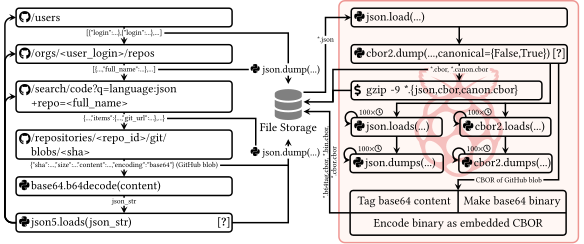

In [4]:
%%tikz -p $preamble
\adjustbox{scale=1.5}{\input{03_json2cbor_eval/figs/json-collect.tex}}

## Dataset Collection

Due to the rate-limiting imposed by GitHub and our method of doing the conversion to CBOR on a Raspberry Pi to achieve reproducible runtimes, the dataset collection can take several weeks.
All information and ways to reproduce this, can be found in [this notebook](03_json2cbor_eval/01_dataset_collection.ipynb).

If you do not have the time for that, we provided our JSON files in `03_json2cbor_eval/jsons.tar.gz` which you can unpack with the following command:

In [5]:
!tar -C "{JSON2CBOR_EVAL_DIR}" -I pigz -xf "{JSON2CBOR_EVAL_DIR}/jsons.tar.gz"

The CBOR files are in `03_json2cbor_eval/cbors.tar.gz` which you can unpack with the following command:

In [6]:
!tar -C "{JSON2CBOR_EVAL_DIR}" -I pigz -xf "{JSON2CBOR_EVAL_DIR}/cbors.tar.gz"

## Initial Dataset Exploration

This provides a broad numeric overview over the dataset of JSONs and CBORs.

In [7]:
df = pandas.read_csv(pathlib.Path(JSON2CBOR_EVAL_DIR) / "json2cbor_rpi3.csv.gz", delimiter=";")
#df = pandas.read_csv(pathlib.Path(JSON2CBOR_EVAL_DIR) / "json2cbor_epyc7702.csv.gz", delimiter=";")
#df = pandas.read_csv(pathlib.Path(JSON2CBOR_EVAL_DIR) / "json2cbor_i7-1280p.csv.gz", delimiter=";")

pandas.DataFrame(
    [
        {
            "total": df.shape[0],
            "github_api": df[df["github_type"] != "stored_json"].shape[0],
            "stored_json": df[df["github_type"] == "stored_json"].shape[0],
            "blobs": df[df["github_type"] == "github_api_blob"].shape[0],
            "unparsable blobs": df[df["github_type"] == "github_api_blob"].shape[0] - df[df["github_type"] == "stored_json"].shape[0],
            "tier_1": df[df["json_size_tier"] == 1].shape[0],
            "tier_2": df[df["json_size_tier"] == 2].shape[0],
            "tier_3": df[df["json_size_tier"] == 3].shape[0],
            "tier_sum": df[df["json_size_tier"].isin([1, 2, 3])].shape[0],
            "textual": df[df["json_content_type"] == "Textual"].shape[0],
            "numeric": df[df["json_content_type"] == "Numeric"].shape[0],
            "boolean": df[df["json_content_type"] == "Boolean"].shape[0],
            "structural": df[df["json_content_type"] == "Structural"].shape[0],
            "content_type_sum": df[df["json_content_type"].isin(["Textual", "Numeric", "Boolean", "Structural"])].shape[0],
            "redundant": df[df["json_redundancy"] == "Redundant"].shape[0],
            "non_redundant": df[df["json_redundancy"] == "Non-redundant"].shape[0],
            "redundancy_sum": df[df["json_redundancy"].isin(["Redundant", "Non-redundant"])].shape[0],
            "flat": df[df["json_structure"] == "Flat"].shape[0],
            "nested": df[df["json_structure"] == "Nested"].shape[0],
            "structure_sum": df[df["json_structure"].isin(["Flat", "Nested"])].shape[0],
            "tier_3_textual_non_redundant_flat": df[(df["json_size_tier"] == 3) & (df["json_content_type"] == "Textual") & (df["json_redundancy"] == "Non-redundant") & (df["json_structure"] == "Flat")].shape[0],
            "stored_tier_1": df[(df["github_type"] == "stored_json") & (df["json_size_tier"] == 1)].shape[0],
            "stored_tier_2": df[(df["github_type"] == "stored_json") & (df["json_size_tier"] == 2)].shape[0],
            "stored_tier_3": df[(df["github_type"] == "stored_json") & (df["json_size_tier"] == 3)].shape[0],
            "stored_tier_sum": df[(df["github_type"] == "stored_json") & df["json_size_tier"].isin([1, 2, 3])].shape[0],
            "stored_textual": df[(df["github_type"] == "stored_json") & (df["json_content_type"] == "Textual")].shape[0],
            "stored_numeric": df[(df["github_type"] == "stored_json") & (df["json_content_type"] == "Numeric")].shape[0],
            "stored_boolean": df[(df["github_type"] == "stored_json") & (df["json_content_type"] == "Boolean")].shape[0],
            "stored_structural": df[(df["github_type"] == "stored_json") & (df["json_content_type"] == "Structural")].shape[0],
            "stored_content_type_sum": df[(df["github_type"] == "stored_json") & df["json_content_type"].isin(["Textual", "Numeric", "Boolean", "Structural"])].shape[0],
            "stored_redundant": df[(df["github_type"] == "stored_json") & (df["json_redundancy"] == "Redundant")].shape[0],
            "stored_non_redundant": df[(df["github_type"] == "stored_json") & (df["json_redundancy"] == "Non-redundant")].shape[0],
            "stored_redundancy_sum": df[(df["github_type"] == "stored_json") & df["json_redundancy"].isin(["Redundant", "Non-redundant"])].shape[0],
            "stored_flat": df[(df["github_type"] == "stored_json") & (df["json_structure"] == "Flat")].shape[0],
            "stored_nested": df[(df["github_type"] == "stored_json") & (df["json_structure"] == "Nested")].shape[0],
            "stored_structure_sum": df[(df["github_type"] == "stored_json") & df["json_structure"].isin(["Flat", "Nested"])].shape[0],
            "start_time": datetime.datetime.fromtimestamp(df["json_mtime"].min()).isoformat(),
            "end_time": datetime.datetime.fromtimestamp(df["json_mtime"].max()).isoformat(),
        }
    ]
).T.rename(columns={0: "count"})

,count
total,287671
github_api,164365
stored_json,123306
blobs,128643
unparsable blobs,5337
tier_1,9604
tier_2,99521
tier_3,178483
tier_sum,287608
textual,275399
